# Brinson-Fachler Attribution Analysis

This notebook implements the Brinson-Fachler performance attribution model on a sector basis.

**Actual Target Allocations:**
Removed the (efa + scz + vss) / 3.0 equal-weight benchmark construction. The weight dynamics imputation now uses the explicit bench_sect_wt_* allocations that are already present in combined_monthly.csv.

**Components of Active Return:**
- **Allocation Effect**: $(W_{P,i} - W_{B,i}) \times (R_{B,i} - R_B)$ 
- **Selection Effect**: $W_{B,i} \times (R_{P,i} - R_{B,i})$ 
- **Interaction Effect**: $(W_{P,i} - W_{B,i}) \times (R_{P,i} - R_{B,i})$

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set plotting aesthetics
sns.set_theme(style="whitegrid")

### 1. Data Loading and Preparation

In [2]:
# Load monthly fund/benchmark data (contains sector weights and total returns)
monthly_df = pd.read_csv('combined_monthly.csv')
monthly_df['month'] = pd.to_datetime(monthly_df['month']).dt.to_period('M')

# Load stock-level panel data (contains individual returns to calculate portfolio sector returns)
panel_df = pd.read_csv('combined_panel.csv')
panel_df['month'] = pd.to_datetime(panel_df['month']).dt.to_period('M')

### 2. Extract Portfolio and Benchmark Sector Weights

In [3]:
# Identify columns for portfolio and benchmark weights
sect_wt_cols = [c for c in monthly_df.columns if c.startswith('sect_wt_')]
bench_sect_wt_cols = [c for c in monthly_df.columns if c.startswith('bench_sect_wt_')]

# Melt portfolio weights into a long format
w_p = monthly_df[['month'] + sect_wt_cols].melt(id_vars='month', var_name='sector', value_name='w_p')
w_p['sector'] = w_p['sector'].str.replace('sect_wt_', '')

# Melt benchmark weights into a long format
w_b = monthly_df[['month'] + bench_sect_wt_cols].melt(id_vars='month', var_name='sector', value_name='w_b')
w_b['sector'] = w_b['sector'].str.replace('bench_sect_wt_', '')

# Merge weights
weights_df = pd.merge(w_p, w_b, on=['month', 'sector'], how='outer').fillna(0)

### 3. Active Tilt Validation (2018 - 2022)
We confirm the textbook small/mid-cap growth posture of the fund by examining the active tilts (Fund vs Blended Benchmark) during the 2018-2022 holdings window.

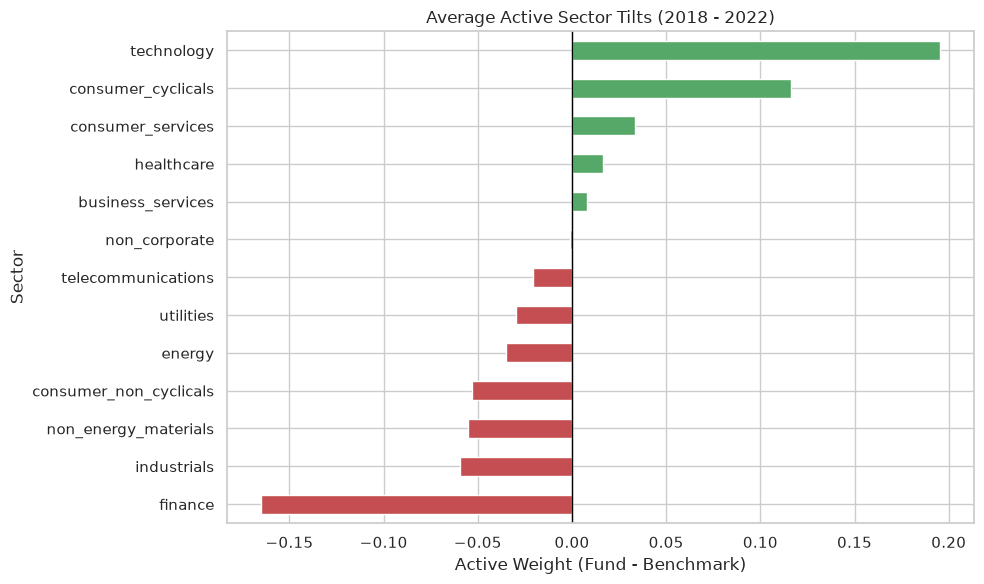

Average Active Tilts (2018-2022) for highlighted sectors:
Healthcare: 1.6%
Technology: 19.5%
Finance: -16.5%
Non_energy_materials: -5.5%


In [4]:
# Filter to the 2018-2022 window
tilt_df = weights_df[(weights_df['month'].dt.year >= 2018) & (weights_df['month'].dt.year <= 2022)].copy()
tilt_df['active_tilt'] = tilt_df['w_p'] - tilt_df['w_b']

# Calculate average tilt per sector
avg_tilt = tilt_df.groupby('sector')['active_tilt'].mean().sort_values()

plt.figure(figsize=(10, 6))
avg_tilt.plot(kind='barh', color=np.where(avg_tilt > 0, '#55a868', '#c44e52'))
plt.title('Average Active Sector Tilts (2018 - 2022)')
plt.xlabel('Active Weight (Fund - Benchmark)')
plt.ylabel('Sector')
plt.axvline(0, color='black', linewidth=1)
plt.tight_layout()
plt.show()

print("Average Active Tilts (2018-2022) for highlighted sectors:")
highlight_sectors = ['healthcare', 'technology', 'finance', 'non_energy_materials']
for s in highlight_sectors:
    if s in avg_tilt:
        print(f"{s.capitalize()}: {avg_tilt[s]:.1%}")

### 4. Calculate Sector Returns ($R_{P,i}$ and $R_{B,i}$)

In [5]:
# Standardize sector names in panel_df to match weights_df format
panel_df['sector_clean'] = panel_df['sector'].astype(str).str.lower().replace(r'[^a-z0-9]', '_', regex=True).replace(r'_+', '_', regex=True)

# Calculate Portfolio Sector Returns (R_p)
r_p = panel_df.groupby(['month', 'sector_clean'])['ret'].mean().reset_index()
r_p.rename(columns={'sector_clean': 'sector', 'ret': 'r_p'}, inplace=True)

# Impute Benchmark Sector Returns using weight-change dynamics from actual target allocations
weight_dynamics = pd.merge(w_b, monthly_df[['month', 'bench_avg_ret']], on='month', how='inner')
weight_dynamics = weight_dynamics.sort_values(['sector', 'month'])
weight_dynamics['prev_w_b'] = weight_dynamics.groupby('sector')['w_b'].shift(1)
weight_dynamics['r_b_imputed'] = (weight_dynamics['w_b'] / weight_dynamics['prev_w_b']) * (1.0 + weight_dynamics['bench_avg_ret']) - 1.0
weight_dynamics['r_b_imputed'] = weight_dynamics['r_b_imputed'].fillna(weight_dynamics['bench_avg_ret'])
weight_dynamics['r_b_imputed'] = weight_dynamics['r_b_imputed'].clip(lower=-0.99, upper=2.0)

# Merge with weights
brinson_df = pd.merge(weights_df, r_p, on=['month', 'sector'], how='left').fillna(0)
brinson_df = pd.merge(brinson_df, weight_dynamics[['month', 'sector', 'r_b_imputed']], on=['month', 'sector'], how='inner')
brinson_df.rename(columns={'r_b_imputed': 'r_b'}, inplace=True)

# Add overall benchmark and portfolio return
monthly_ret = monthly_df[['month', 'bench_avg_ret', 'fund_ret']].copy()
monthly_ret.rename(columns={'bench_avg_ret': 'R_B_total', 'fund_ret': 'R_P_total'}, inplace=True)
brinson_df = pd.merge(brinson_df, monthly_ret, on='month', how='left')


### 5. Compute Brinson-Fachler Effects

In [6]:
# Single-period effects
brinson_df['allocation_unlinked'] = (brinson_df['w_p'] - brinson_df['w_b']) * (brinson_df['r_b'] - brinson_df['R_B_total'])
brinson_df['selection_unlinked'] = brinson_df['w_b'] * (brinson_df['r_p'] - brinson_df['r_b'])
brinson_df['interaction_unlinked'] = (brinson_df['w_p'] - brinson_df['w_b']) * (brinson_df['r_p'] - brinson_df['r_b'])

# Multi-Period Linking (Carino/Menchero)
def calc_carino(rp_s, rb_s):
    Rp = np.prod(1 + rp_s) - 1
    Rb = np.prod(1 + rb_s) - 1
    K = 1 / (1 + Rp) if np.isclose(Rp, Rb) else (Rp - Rb) / (np.log(1 + Rp) - np.log(1 + Rb))
    kt = np.where(np.isclose(rp_s, rb_s), 1 / (1 + rp_s), (rp_s - rb_s) / (np.log(1 + rp_s) - np.log(1 + rb_s)))
    return K / kt

monthly_totals = brinson_df.groupby('month')[['R_P_total', 'R_B_total']].first().reset_index()
monthly_totals['linking_coef'] = calc_carino(monthly_totals['R_P_total'].values, monthly_totals['R_B_total'].values)
brinson_df = pd.merge(brinson_df, monthly_totals[['month', 'linking_coef']], on='month', how='left')

brinson_df['allocation'] = brinson_df['allocation_unlinked'] * brinson_df['linking_coef']
brinson_df['selection'] = brinson_df['selection_unlinked'] * brinson_df['linking_coef']
brinson_df['interaction'] = brinson_df['interaction_unlinked'] * brinson_df['linking_coef']
brinson_df['total_active_return'] = brinson_df['allocation'] + brinson_df['selection'] + brinson_df['interaction']


### 6. Aggregate and Visualize Results

In [7]:
# Sum the effects across all months by sector
summary_df = brinson_df.groupby('sector')[['allocation', 'selection', 'interaction', 'total_active_return']].sum().reset_index()
summary_df = summary_df.sort_values(by='total_active_return', ascending=False)

display(summary_df)

,sector,allocation,selection,interaction,total_active_return
10,technology,0.023990,0.046113,0.342244,0.412346
3,consumer_services,-0.010121,0.045890,0.101924,0.137693
6,healthcare,0.017175,0.007163,0.039199,0.063536
0,business_services,-0.002980,-0.002602,0.051219,0.045637
1,consumer_cyclicals,0.014112,-0.017611,0.038561,0.035062
9,non_energy_materials,-0.004534,0.040188,-0.006438,0.029216
5,finance,-0.001543,-0.115641,0.135795,0.018611
4,energy,0.015711,1.098688,-1.098537,0.015862
11,telecommunications,0.013696,0.015252,-0.015252,0.013696
12,utilities,-0.010065,-0.005804,0.005804,-0.010065


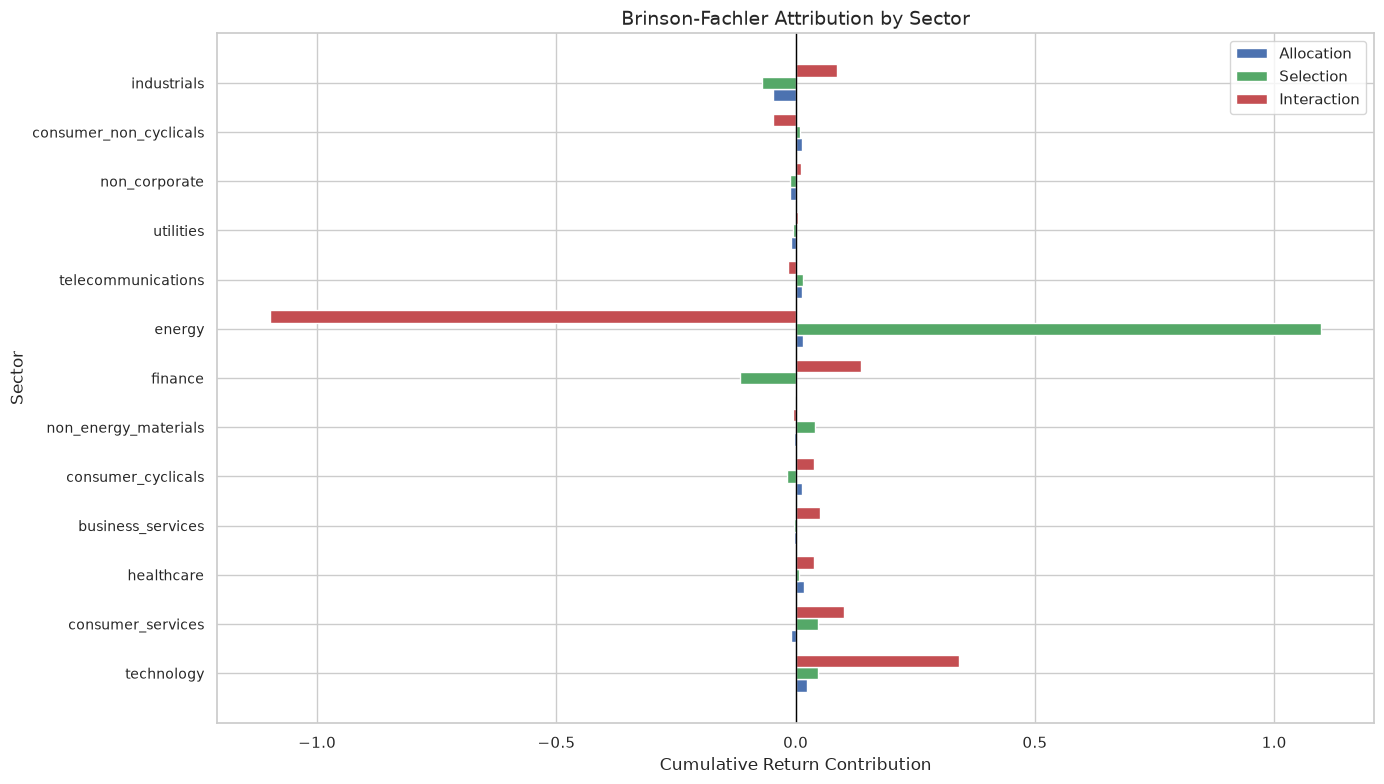

In [8]:
# Plot the attribution summary
plt.figure(figsize=(14, 8))
y = np.arange(len(summary_df['sector']))
height = 0.25

plt.barh(y - height, summary_df['allocation'], height, label='Allocation', color='#4c72b0')
plt.barh(y, summary_df['selection'], height, label='Selection', color='#55a868')
plt.barh(y + height, summary_df['interaction'], height, label='Interaction', color='#c44e52')

plt.yticks(y, summary_df['sector'], fontsize=10)
plt.xlabel('Cumulative Return Contribution', fontsize=12)
plt.ylabel('Sector', fontsize=12)
plt.title('Brinson-Fachler Attribution by Sector', fontsize=14)
plt.axvline(0, color='black', linewidth=1)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()